In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from training.train_new import run_training

In [4]:
seeds = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50]

conditions = [
    ("high", "social"),
    ("high", "non_social"),
    ("no", "social"),
    ("no", "non_social"),
]

results_list = []

for variance, cue in conditions:
    for seed in seeds:
        _, results = run_training(
            variance_condition=variance,
            cue_type=cue,
            n_episodes=5000,
            cue_reliability=0.85,
            seed=seed
        )

        results_list.append({
            "variance": variance,
            "cue_type": cue,
            "seed": seed,
            "final_chosen_cue_rate": results["final_chosen_cue_rate"],
            "final_actual_cue_rate": results["final_actual_cue_rate"],
            "final_avg_reward": results["final_avg_reward"]
        })

df = pd.DataFrame(results_list)
df.head()

c:\Users\diamo\miniforge3\envs\beeRL\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\diamo\miniforge3\envs\beeRL\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(



Training: variance=high, cue=social
Episodes: 5000 | Cue reliability: 0.85
----------------------------------------------------------------------
Episode   500 | Avg reward:  289.0 | Chosen cue rate: 0.66 | Actual cue rate: 0.66 | Epsilon: 0.606
Episode  1000 | Avg reward:  327.5 | Chosen cue rate: 0.74 | Actual cue rate: 0.74 | Epsilon: 0.368
Episode  1500 | Avg reward:  316.5 | Chosen cue rate: 0.76 | Actual cue rate: 0.76 | Epsilon: 0.223
Episode  2000 | Avg reward:  381.0 | Chosen cue rate: 0.88 | Actual cue rate: 0.88 | Epsilon: 0.135
Episode  2500 | Avg reward:  348.5 | Chosen cue rate: 0.84 | Actual cue rate: 0.84 | Epsilon: 0.082
Episode  3000 | Avg reward:  376.0 | Chosen cue rate: 0.92 | Actual cue rate: 0.92 | Epsilon: 0.050
Episode  3500 | Avg reward:  410.5 | Chosen cue rate: 0.95 | Actual cue rate: 0.95 | Epsilon: 0.050
Episode  4000 | Avg reward:  377.5 | Chosen cue rate: 0.90 | Actual cue rate: 0.90 | Epsilon: 0.050
Episode  4500 | Avg reward:  391.0 | Chosen cue rate:

,variance,cue_type,seed,final_chosen_cue_rate,final_actual_cue_rate,final_avg_reward
0,high,social,1,0.9565,0.9565,421.0
1,high,social,2,0.9650,0.9650,424.5
2,high,social,3,0.8415,0.8415,364.0
3,high,social,4,0.9685,0.9685,404.5
4,high,social,5,0.9510,0.9510,436.5


In [5]:
summary = (
    df.groupby(["variance", "cue_type"])
      .agg(
          mean_cue_rate=("final_chosen_cue_rate", "mean"),
          std_cue_rate=("final_chosen_cue_rate", "std"),
          mean_act_cue_rate=("final_actual_cue_rate", "mean"),
          std_act_cue_rate=("final_actual_cue_rate", "std"),
          mean_reward=("final_avg_reward", "mean"),
          std_reward=("final_avg_reward", "std")
      )
      .reset_index()
)

summary

,variance,cue_type,mean_cue_rate,std_cue_rate,mean_act_cue_rate,std_act_cue_rate,mean_reward,std_reward
0,high,non_social,0.81130,0.039173,0.71400,0.016450,304.550000,8.401223
1,high,social,0.92085,0.050864,0.92085,0.050864,399.450000,24.782891
2,no,non_social,0.44790,0.079412,0.32260,0.105090,163.978333,0.875747
3,no,social,0.09875,0.029537,0.09870,0.029567,162.554167,1.231977


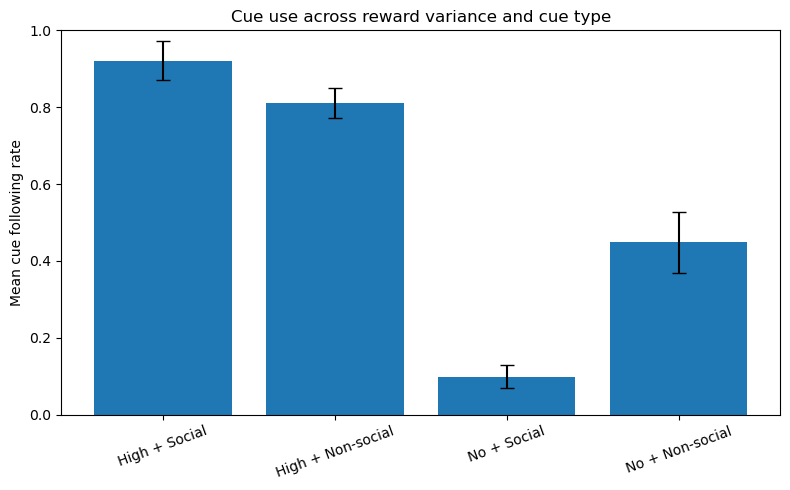

In [6]:
labels = [
    "High + Social",
    "High + Non-social",
    "No + Social",
    "No + Non-social"
]

ordered = [
    ("high", "social"),
    ("high", "non_social"),
    ("no", "social"),
    ("no", "non_social")
]

means = []
stds = []

for variance, cue in ordered:
    row = summary[
        (summary["variance"] == variance) &
        (summary["cue_type"] == cue)
    ]
    means.append(row["mean_cue_rate"].values[0])
    stds.append(row["std_cue_rate"].values[0])

plt.figure(figsize=(8, 5))
plt.bar(labels, means, yerr=stds, capsize=5)
plt.ylabel("Mean cue following rate")
plt.title("Cue use across reward variance and cue type")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [7]:
summary = (
    df.groupby(["variance", "cue_type"])
      .agg(
          mean_cue_rate=("final_cue_rate", "mean"),
          std_cue_rate=("final_cue_rate", "std"),
          n=("final_cue_rate", "count")
      )
      .reset_index()
)

summary["sem"] = summary["std_cue_rate"] / np.sqrt(summary["n"])

summary

KeyError: "Column(s) ['final_cue_rate'] do not exist"

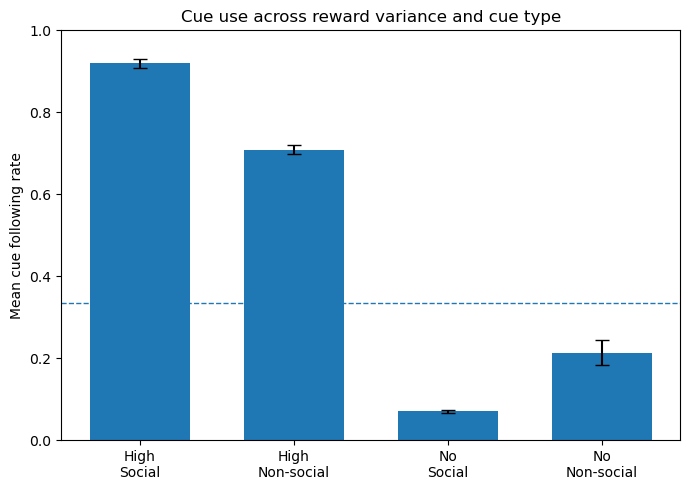

In [6]:
import numpy as np
import matplotlib.pyplot as plt

labels = [
    "High\nSocial",
    "High\nNon-social",
    "No\nSocial",
    "No\nNon-social"
]

ordered = [
    ("high", "social"),
    ("high", "non_social"),
    ("no", "social"),
    ("no", "non_social")
]

means = []
errors = []

for variance, cue in ordered:
    row = summary[
        (summary["variance"] == variance) &
        (summary["cue_type"] == cue)
    ]
    means.append(row["mean_cue_rate"].values[0])
    errors.append(row["sem"].values[0])

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    x,
    means,
    yerr=errors,
    capsize=5,
    width=0.65
)

# Chance level line (important)
ax.axhline(
    y=1/3,
    linestyle="--",
    linewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean cue following rate")
ax.set_ylim(0, 1)
ax.set_title("Cue use across reward variance and cue type")

plt.tight_layout()
plt.show()

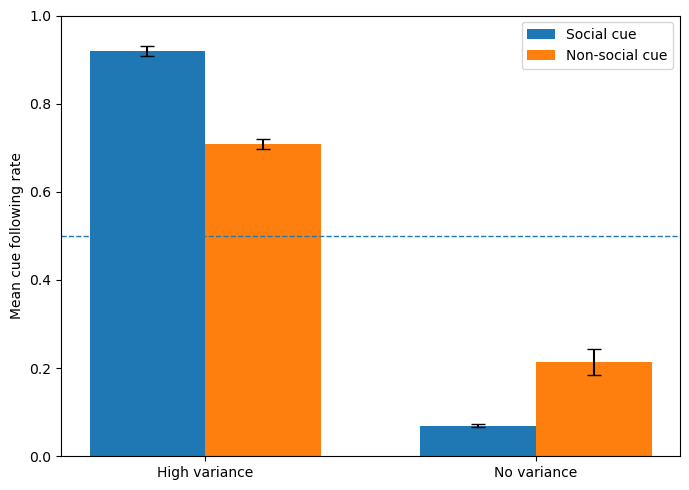

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

x = np.array([0, 1])   # high variance, no variance
width = 0.35

social_means = []
social_err = []
nonsocial_means = []
nonsocial_err = []

for variance in ["high", "no"]:
    row_social = summary[
        (summary["variance"] == variance) &
        (summary["cue_type"] == "social")
    ]
    row_non = summary[
        (summary["variance"] == variance) &
        (summary["cue_type"] == "non_social")
    ]

    social_means.append(row_social["mean_cue_rate"].values[0])
    social_err.append(row_social["sem"].values[0])

    nonsocial_means.append(row_non["mean_cue_rate"].values[0])
    nonsocial_err.append(row_non["sem"].values[0])

ax.bar(
    x - width/2,
    social_means,
    width,
    yerr=social_err,
    capsize=5,
    label="Social cue"
)

ax.bar(
    x + width/2,
    nonsocial_means,
    width,
    yerr=nonsocial_err,
    capsize=5,
    label="Non-social cue"
)

ax.axhline(1/2, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(["High variance", "No variance"])
ax.set_ylabel("Mean cue following rate")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

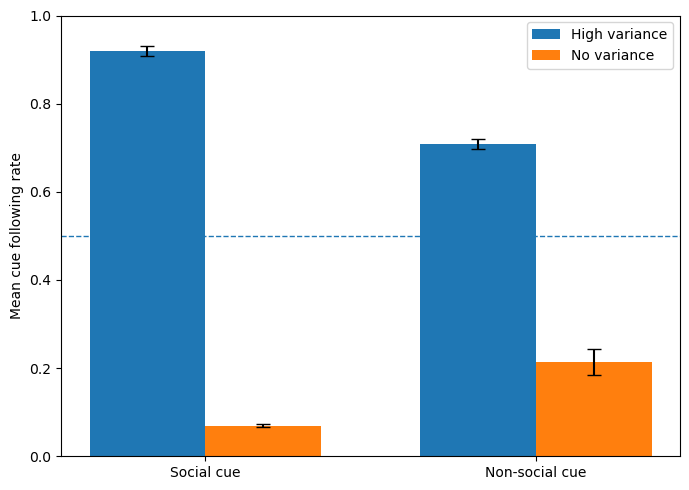

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

x = np.array([0, 1])   # social, non-social
width = 0.35

high_means = []
high_err = []
no_means = []
no_err = []

for cue in ["social", "non_social"]:
    row_high = summary[
        (summary["variance"] == "high") &
        (summary["cue_type"] == cue)
    ]
    row_no = summary[
        (summary["variance"] == "no") &
        (summary["cue_type"] == cue)
    ]

    high_means.append(row_high["mean_cue_rate"].values[0])
    high_err.append(row_high["sem"].values[0])

    no_means.append(row_no["mean_cue_rate"].values[0])
    no_err.append(row_no["sem"].values[0])

ax.bar(
    x - width/2,
    high_means,
    width,
    yerr=high_err,
    capsize=5,
    label="High variance"
)

ax.bar(
    x + width/2,
    no_means,
    width,
    yerr=no_err,
    capsize=5,
    label="No variance"
)

ax.axhline(0.5, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(["Social cue", "Non-social cue"])
ax.set_ylabel("Mean cue following rate")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()